In [9]:
import pandas as pd
import numpy as np

# Preprocesamiento de texto
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Division de datos
from sklearn.model_selection import train_test_split

# Construccion del modelo
from tensorflow.keras.models import Sequential

# Capas
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Activation
)

# Regularizacion
from tensorflow.keras.regularizers import l2

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping

# Optimizador
from tensorflow.keras.optimizers import Adam

# Metricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Visualizacion
import matplotlib.pyplot as plt

# Dataset
df = pd.read_csv("IMDB Dataset.csv")

In [10]:
# eliminar duplicados
df = df.drop_duplicates()

# Ya que el tipo de dato de la columna "sentiment" es texto
# conviene convertirlo a boolean siendo 1 positive y 0 negative

df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

# Separo las variables, en este caso review sera nuestro
# dato de entrada y sentiment sera nuestro target

X = df["review"]
y = df["sentiment"]

# Tokenizo la informacion para que pueda ser procesada por la red neuronal
# pasando de texto a datos estructurados

# Conviene limitar el vocabulario, en este caso a las 10000 palabras
# mas comunes para disminuir el "Ruido" en la prediccion de datos mas adelante.
# Esto tambien reduce el tiempo de entrenamiento

max_words = 10000

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X)

sequences = tokenizer.texts_to_sequences(X)

# En el siguiente paso aplico un padding a los datos ya tokenizados
# para asegurar que todas las matrices de datos tengan el mismo tamaño.
# La longitud en la que dejaremos los datos viene del promedio del largo
# de las reseñas del sitio imdb (100 - 300 palabras aprox)

max_len = 200

X_pad = pad_sequences(sequences, maxlen=max_len)

# Se hace el split de los datos

X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y, test_size=0.2, random_state=42
)

# Definicion del modelo secuencial

model = Sequential([
    Input(shape=(200,)),
    Embedding(input_dim=10000, output_dim=32),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compilacion del modelo

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Evaluacion del Modelo Baseline

En esta seccion se entrena el modelo baseline y se evalua su desempeño utilizando las metricas accuracy, precision, recall y F1-score. Ademas, se generan graficos de loss y accuracy para analizar visualmente el comportamiento del modelo durante el entrenamiento y detectar posibles señales de overfitting.

Epoch 1/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7912 - loss: 0.4154 - val_accuracy: 0.8717 - val_loss: 0.2977
Epoch 2/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9440 - loss: 0.1538 - val_accuracy: 0.8539 - val_loss: 0.3699
Epoch 3/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9920 - loss: 0.0308 - val_accuracy: 0.8535 - val_loss: 0.4828
Epoch 4/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9993 - loss: 0.0050 - val_accuracy: 0.8540 - val_loss: 0.5979
Epoch 5/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 1.0000 - loss: 5.3999e-04 - val_accuracy: 0.8594 - val_loss: 0.6614
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Metricas Baseline
-------------------
Accuracy : 0.8618533830795604
Precision: 0.8569449940641076
Recall   : 0.8700281237444757
F1-score : 0.8634370015948963


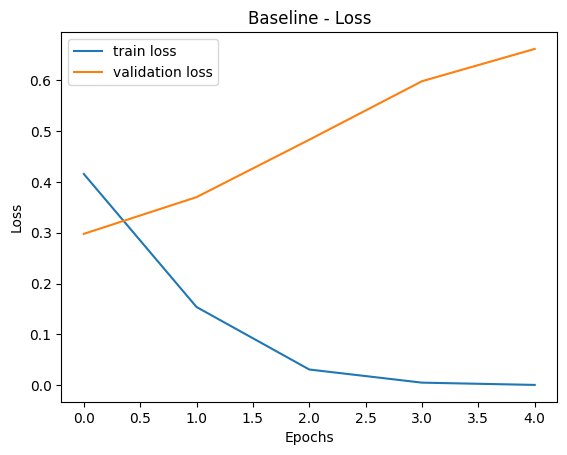

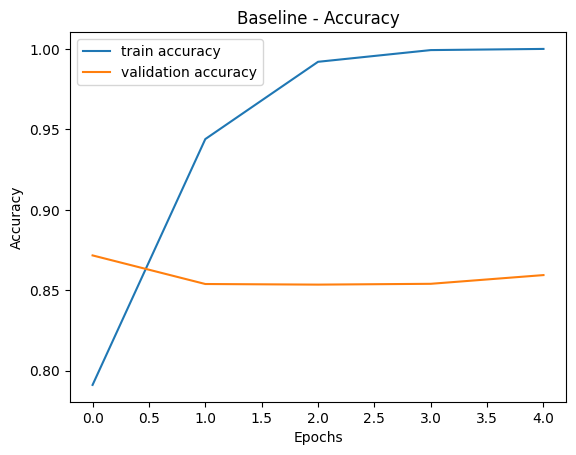

In [11]:
# Entrenamiento del modelo baseline

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# Predicciones del modelo

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

# Calculo de metricas

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Mostrar metricas

print("Metricas Baseline")
print("-------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

# Grafico de loss

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Baseline - Loss')

plt.legend()
plt.show()

# Grafico de accuracy

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Baseline - Accuracy')

plt.legend()
plt.show()

## L2 Regularization

En esta seccion se implementa la tecnica de regularizacion L2 sobre el modelo baseline. Esta tecnica agrega una penalizacion a los pesos grandes del modelo con el objetivo de reducir el overfitting y mejorar la capacidad de generalizacion.

Se probaran dos valores distintos de lambda:
- 0.05
- 0.01

Para cada configuracion se evaluaran las metricas accuracy, precision, recall y F1-score, ademas de las curvas de loss y accuracy para analizar el comportamiento del modelo durante el entrenamiento.

Finalmente, se compararan ambos resultados para identificar cual valor de regularizacion reduce de mejor manera el overfitting sin afectar excesivamente la capacidad de aprendizaje del modelo.

Epoch 1/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.6912 - loss: 0.7150 - val_accuracy: 0.8481 - val_loss: 0.4859
Epoch 2/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8797 - loss: 0.4090 - val_accuracy: 0.8708 - val_loss: 0.4055
Epoch 3/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8988 - loss: 0.3507 - val_accuracy: 0.8694 - val_loss: 0.3976
Epoch 4/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9138 - loss: 0.3163 - val_accuracy: 0.8766 - val_loss: 0.3817
Epoch 5/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9241 - loss: 0.2899 - val_accuracy: 0.8689 - val_loss: 0.3821
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Metricas L2 lambda = 0.05
----------------------------
Accuracy : 0.8697186649188262
Precision: 0.8943089430894309
Recall   : 0.8396946564885496
F1-score : 0.8661417322834646


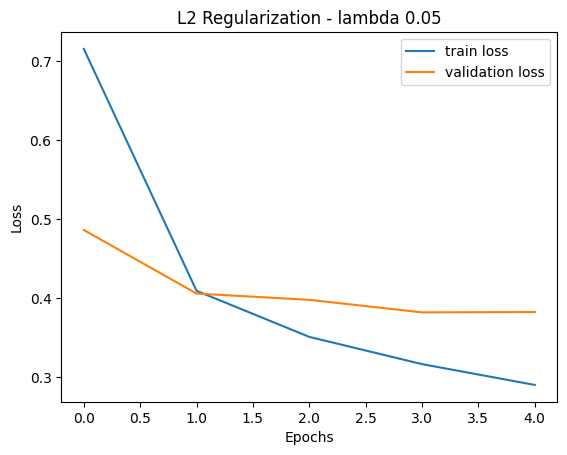

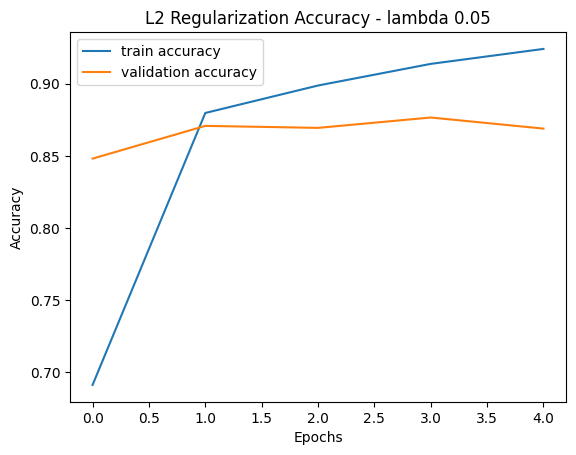

Epoch 1/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.7906 - loss: 0.5085 - val_accuracy: 0.8651 - val_loss: 0.3863
Epoch 2/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8998 - loss: 0.3214 - val_accuracy: 0.8747 - val_loss: 0.3624
Epoch 3/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9251 - loss: 0.2666 - val_accuracy: 0.8773 - val_loss: 0.3628
Epoch 4/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9529 - loss: 0.2136 - val_accuracy: 0.8705 - val_loss: 0.4097
Epoch 5/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9753 - loss: 0.1631 - val_accuracy: 0.8750 - val_loss: 0.4199
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Metricas L2 lambda = 0.01
---------------------------
Accuracy : 0.8736513058384592
Precision: 0.86115958890828
Recall   : 0.892125351546806
F1-score : 0.8763690182535767


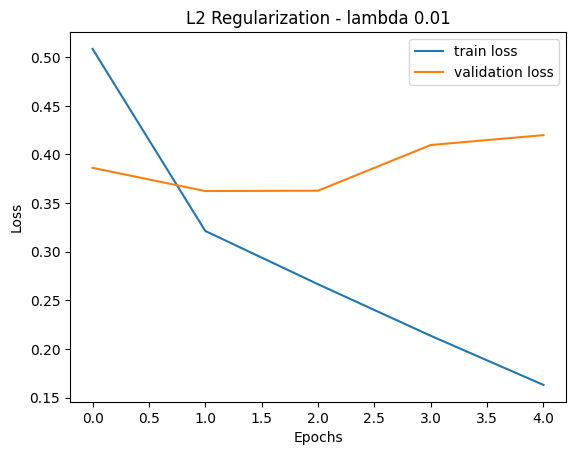

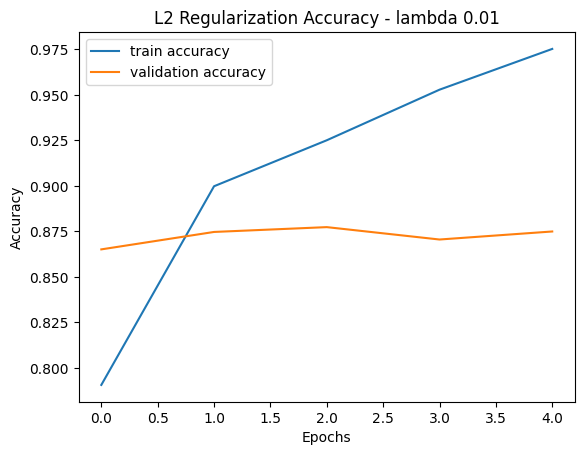

In [19]:
# MODELO CON L2 = 0.05

model_l2_005 = Sequential([

    Input(shape=(200,)),

    Embedding(
        input_dim=10000,
        output_dim=32
    ),

    Flatten(),

    Dense(
        16,
        activation='relu',
        kernel_regularizer=l2(0.05)
    ),

    Dense(
        8,
        activation='relu',
        kernel_regularizer=l2(0.05)
    ),

    Dense(1, activation='sigmoid')
])

# Compilacion del modelo

model_l2_005.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento del modelo

history_l2_005 = model_l2_005.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# Predicciones

y_pred_l2_005 = model_l2_005.predict(X_test)
y_pred_l2_005 = (y_pred_l2_005 > 0.5).astype(int)

# Metricas

accuracy_l2_005 = accuracy_score(y_test, y_pred_l2_005)
precision_l2_005 = precision_score(y_test, y_pred_l2_005)
recall_l2_005 = recall_score(y_test, y_pred_l2_005)
f1_l2_005 = f1_score(y_test, y_pred_l2_005)

# Mostrar metricas

print("Metricas L2 lambda = 0.05")
print("----------------------------")
print("Accuracy :", accuracy_l2_005)
print("Precision:", precision_l2_005)
print("Recall   :", recall_l2_005)
print("F1-score :", f1_l2_005)

# Grafico Loss

plt.plot(history_l2_005.history['loss'], label='train loss')
plt.plot(history_l2_005.history['val_loss'], label='validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('L2 Regularization - lambda 0.05')

plt.legend()
plt.show()

# Grafico Accuracy

plt.plot(history_l2_005.history['accuracy'], label='train accuracy')
plt.plot(history_l2_005.history['val_accuracy'], label='validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('L2 Regularization Accuracy - lambda 0.05')

plt.legend()
plt.show()


# MODELO CON L2 = 0.01

model_l2_01 = Sequential([

    Input(shape=(200,)),

    Embedding(
        input_dim=10000,
        output_dim=32
    ),

    Flatten(),

    Dense(
        16,
        activation='relu',
        kernel_regularizer=l2(0.01)
    ),

    Dense(
        8,
        activation='relu',
        kernel_regularizer=l2(0.01)
    ),

    Dense(1, activation='sigmoid')
])

# Compilacion del modelo

model_l2_01.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento del modelo

history_l2_01 = model_l2_01.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# Predicciones

y_pred_l2_01 = model_l2_01.predict(X_test)
y_pred_l2_01 = (y_pred_l2_01 > 0.5).astype(int)

# Metricas

accuracy_l2_01 = accuracy_score(y_test, y_pred_l2_01)
precision_l2_01 = precision_score(y_test, y_pred_l2_01)
recall_l2_01 = recall_score(y_test, y_pred_l2_01)
f1_l2_01 = f1_score(y_test, y_pred_l2_01)

# Mostrar metricas

print("Metricas L2 lambda = 0.01")
print("---------------------------")
print("Accuracy :", accuracy_l2_01)
print("Precision:", precision_l2_01)
print("Recall   :", recall_l2_01)
print("F1-score :", f1_l2_01)

# Grafico Loss

plt.plot(history_l2_01.history['loss'], label='train loss')
plt.plot(history_l2_01.history['val_loss'], label='validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('L2 Regularization - lambda 0.01')

plt.legend()
plt.show()

# Grafico Accuracy

plt.plot(history_l2_01.history['accuracy'], label='train accuracy')
plt.plot(history_l2_01.history['val_accuracy'], label='validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('L2 Regularization Accuracy - lambda 0.01')

plt.legend()
plt.show()

## Dropout

En esta seccion se implementa la tecnica de regularizacion Dropout sobre el modelo baseline. Dropout desactiva aleatoriamente un porcentaje de neuronas durante el entrenamiento, obligando al modelo a no depender excesivamente de conexiones especificas y reduciendo el overfitting.

Se probaran dos tasas distintas de Dropout:
- 0.3
- 0.8

El objetivo es comparar una regularizacion moderada frente a una extremadamente agresiva y analizar como afecta la capacidad de aprendizaje y generalizacion del modelo.

Para cada configuracion se evaluaran las metricas accuracy, precision, recall y F1-score, ademas de las curvas de loss y accuracy.

Epoch 1/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.7549 - loss: 0.4752 - val_accuracy: 0.8738 - val_loss: 0.3022
Epoch 2/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9163 - loss: 0.2363 - val_accuracy: 0.8433 - val_loss: 0.3725
Epoch 3/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9628 - loss: 0.1164 - val_accuracy: 0.8565 - val_loss: 0.4478
Epoch 4/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9811 - loss: 0.0614 - val_accuracy: 0.8525 - val_loss: 0.6129
Epoch 5/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9861 - loss: 0.0433 - val_accuracy: 0.8505 - val_loss: 0.7732
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Metricas Dropout 0.3
----------------------
Accuracy : 0.8580215791065846
Precision: 0.8647323252962812
Recall   : 0.8501406187223784
F1-score : 0.8573743922204214


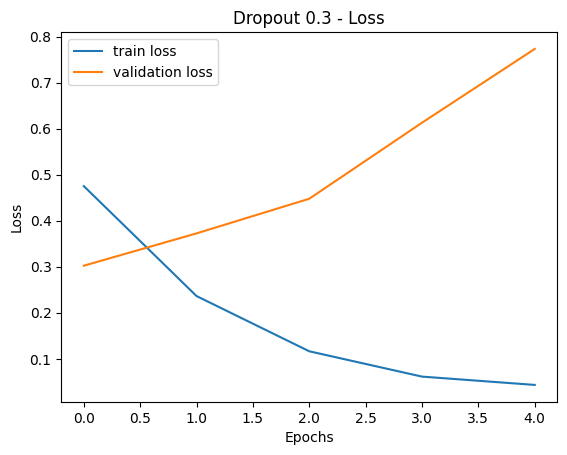

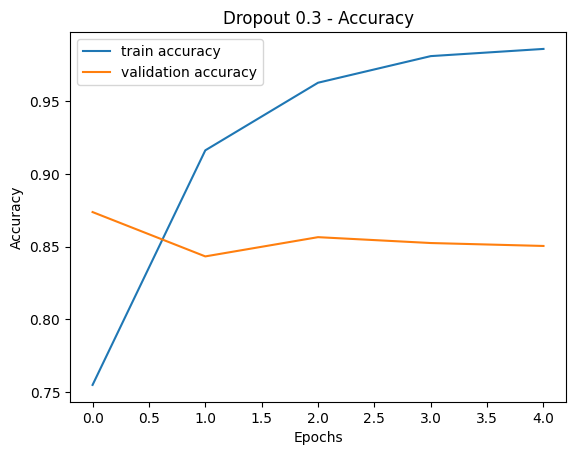

Epoch 1/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5026 - loss: 0.6938 - val_accuracy: 0.5583 - val_loss: 0.6925
Epoch 2/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.5528 - loss: 0.6708 - val_accuracy: 0.8156 - val_loss: 0.5444
Epoch 3/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.6475 - loss: 0.5966 - val_accuracy: 0.8548 - val_loss: 0.4263
Epoch 4/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6866 - loss: 0.5526 - val_accuracy: 0.8646 - val_loss: 0.3841
Epoch 5/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7133 - loss: 0.5166 - val_accuracy: 0.8623 - val_loss: 0.3596
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Metricas Dropout 0.8
----------------------
Accuracy : 0.8581224160532419
Precision: 0.8406792596832665
Recall   : 0.8850944154278827
F1-score : 0.8623152950386535


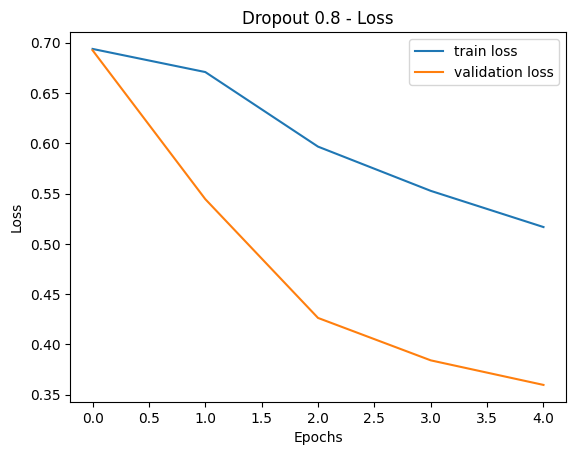

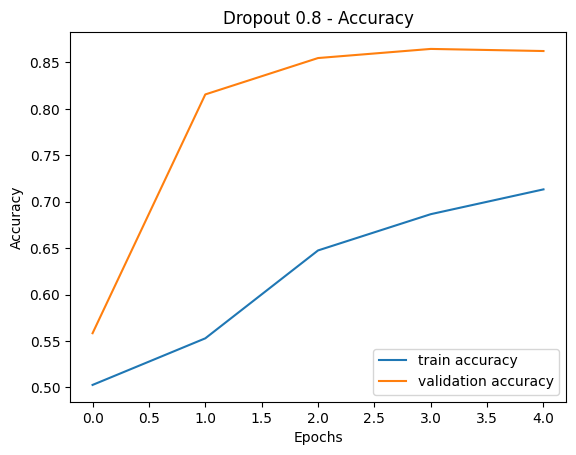

In [14]:
# Modelo con Dropout 0.3

model_dropout_03 = Sequential([

    Input(shape=(200,)),

    Embedding(
        input_dim=10000,
        output_dim=32
    ),

    Flatten(),

    Dense(16, activation='relu'),
    Dropout(0.3),

    Dense(8, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

# Compilacion del modelo

model_dropout_03.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento del modelo

history_dropout_03 = model_dropout_03.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# Predicciones del modelo

y_pred_dropout_03 = model_dropout_03.predict(X_test)
y_pred_dropout_03 = (y_pred_dropout_03 > 0.5).astype(int)

# Calculo de metricas

accuracy_dropout_03 = accuracy_score(y_test, y_pred_dropout_03)
precision_dropout_03 = precision_score(y_test, y_pred_dropout_03)
recall_dropout_03 = recall_score(y_test, y_pred_dropout_03)
f1_dropout_03 = f1_score(y_test, y_pred_dropout_03)

# Mostrar metricas

print("Metricas Dropout 0.3")
print("----------------------")
print("Accuracy :", accuracy_dropout_03)
print("Precision:", precision_dropout_03)
print("Recall   :", recall_dropout_03)
print("F1-score :", f1_dropout_03)

# Grafico de loss

plt.plot(history_dropout_03.history['loss'], label='train loss')
plt.plot(history_dropout_03.history['val_loss'], label='validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Dropout 0.3 - Loss')

plt.legend()
plt.show()

# Grafico de accuracy

plt.plot(history_dropout_03.history['accuracy'], label='train accuracy')
plt.plot(history_dropout_03.history['val_accuracy'], label='validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Dropout 0.3 - Accuracy')

plt.legend()
plt.show()


# Modelo con Dropout 0.8

model_dropout_08 = Sequential([

    Input(shape=(200,)),

    Embedding(
        input_dim=10000,
        output_dim=32
    ),

    Flatten(),

    Dense(16, activation='relu'),
    Dropout(0.8),

    Dense(8, activation='relu'),
    Dropout(0.8),

    Dense(1, activation='sigmoid')
])

# Compilacion del modelo

model_dropout_08.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento del modelo

history_dropout_08 = model_dropout_08.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# Predicciones del modelo

y_pred_dropout_08 = model_dropout_08.predict(X_test)
y_pred_dropout_08 = (y_pred_dropout_08 > 0.5).astype(int)

# Calculo de metricas

accuracy_dropout_08 = accuracy_score(y_test, y_pred_dropout_08)
precision_dropout_08 = precision_score(y_test, y_pred_dropout_08)
recall_dropout_08 = recall_score(y_test, y_pred_dropout_08)
f1_dropout_08 = f1_score(y_test, y_pred_dropout_08)

# Mostrar metricas

print("Metricas Dropout 0.8")
print("----------------------")
print("Accuracy :", accuracy_dropout_08)
print("Precision:", precision_dropout_08)
print("Recall   :", recall_dropout_08)
print("F1-score :", f1_dropout_08)

# Grafico de loss

plt.plot(history_dropout_08.history['loss'], label='train loss')
plt.plot(history_dropout_08.history['val_loss'], label='validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Dropout 0.8 - Loss')

plt.legend()
plt.show()

# Grafico de accuracy

plt.plot(history_dropout_08.history['accuracy'], label='train accuracy')
plt.plot(history_dropout_08.history['val_accuracy'], label='validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Dropout 0.8 - Accuracy')

plt.legend()
plt.show()

## Batch Normalization

En esta seccion se implementa la tecnica Batch Normalization sobre una nueva copia del modelo baseline. Batch Normalization normaliza las activaciones internas de la red neuronal durante el entrenamiento, ayudando a estabilizar el aprendizaje y acelerar la convergencia del modelo.

Segun la arquitectura recomendada para esta tecnica, la normalizacion se aplica entre la capa Dense y la funcion de activacion.

Se evaluaran las metricas accuracy, precision, recall y F1-score, ademas de las curvas de loss y accuracy para analizar el impacto de Batch Normalization sobre la estabilidad del entrenamiento y la capacidad de generalizacion del modelo.

Epoch 1/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7628 - loss: 0.4642 - val_accuracy: 0.8688 - val_loss: 0.3077
Epoch 2/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9245 - loss: 0.2010 - val_accuracy: 0.8547 - val_loss: 0.3558
Epoch 3/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9718 - loss: 0.0865 - val_accuracy: 0.8467 - val_loss: 0.4502
Epoch 4/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9827 - loss: 0.0510 - val_accuracy: 0.8402 - val_loss: 0.5379
Epoch 5/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9854 - loss: 0.0401 - val_accuracy: 0.8513 - val_loss: 0.5333
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Metricas Batch Normalization
------------------------------
Accuracy : 0.849853786427347
Precision: 0.8492492492492493
Recall   : 0.8521494576134994
F1-score : 0.8506968815802667


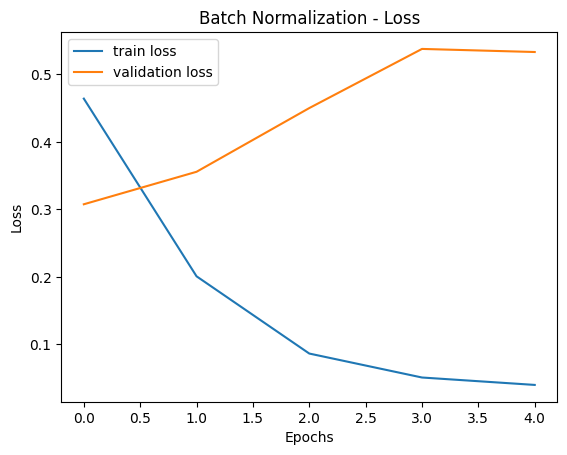

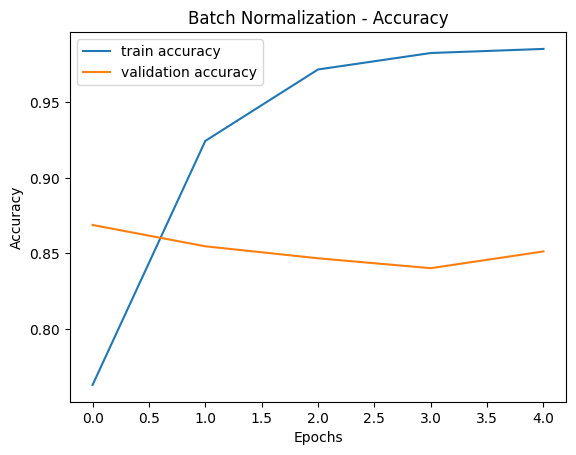

In [15]:
# Modelo con Batch Normalization

model_bn = Sequential([

    Input(shape=(200,)),

    Embedding(
        input_dim=10000,
        output_dim=32
    ),

    Flatten(),

    Dense(16),
    BatchNormalization(),
    Activation('relu'),

    Dense(8),
    BatchNormalization(),
    Activation('relu'),

    Dense(1, activation='sigmoid')
])

# Compilacion del modelo

model_bn.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento del modelo

history_bn = model_bn.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# Predicciones del modelo

y_pred_bn = model_bn.predict(X_test)
y_pred_bn = (y_pred_bn > 0.5).astype(int)

# Calculo de metricas

accuracy_bn = accuracy_score(y_test, y_pred_bn)
precision_bn = precision_score(y_test, y_pred_bn)
recall_bn = recall_score(y_test, y_pred_bn)
f1_bn = f1_score(y_test, y_pred_bn)

# Mostrar metricas

print("Metricas Batch Normalization")
print("------------------------------")
print("Accuracy :", accuracy_bn)
print("Precision:", precision_bn)
print("Recall   :", recall_bn)
print("F1-score :", f1_bn)

# Grafico de loss

plt.plot(history_bn.history['loss'], label='train loss')
plt.plot(history_bn.history['val_loss'], label='validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Batch Normalization - Loss')

plt.legend()
plt.show()

# Grafico de accuracy

plt.plot(history_bn.history['accuracy'], label='train accuracy')
plt.plot(history_bn.history['val_accuracy'], label='validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Batch Normalization - Accuracy')

plt.legend()
plt.show()

## Early Stopping

En esta seccion se implementa la tecnica Early Stopping sobre una nueva copia del modelo baseline. Early Stopping permite detener automaticamente el entrenamiento cuando la metrica de validacion deja de mejorar, evitando continuar el entrenamiento durante fases de sobreajuste.

Debido a que el modelo baseline utiliza solo 5 epocas y el overfitting comienza tempranamente, se probaran configuraciones de patience mas pequeñas:
- patience = 1
- patience = 3

Ademas, se utilizara restore_best_weights=True para recuperar automaticamente los mejores pesos obtenidos durante el entrenamiento.

El objetivo es analizar en que momento se detiene el entrenamiento y como influye esta tecnica sobre las metricas y curvas de validacion del modelo.

Epoch 1/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8063 - loss: 0.3939 - val_accuracy: 0.8719 - val_loss: 0.2988
Epoch 2/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9513 - loss: 0.1376 - val_accuracy: 0.8626 - val_loss: 0.3718
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Metricas Early Stopping patience = 1
--------------------------------------
Accuracy : 0.8697186649188262
Precision: 0.8419294990723563
Recall   : 0.911611088790679
F1-score : 0.8753858024691358
Entrenamiento detenido en epoch: 2


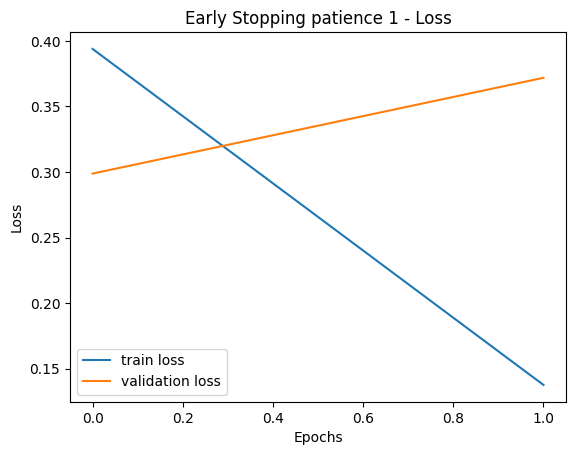

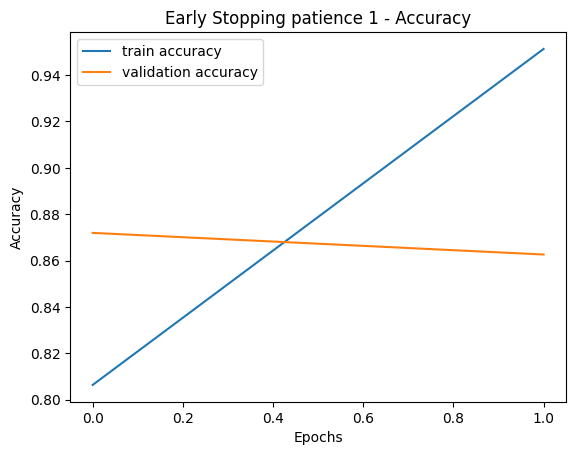

Epoch 1/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8039 - loss: 0.3955 - val_accuracy: 0.8505 - val_loss: 0.3295
Epoch 2/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9457 - loss: 0.1516 - val_accuracy: 0.8565 - val_loss: 0.3629
Epoch 3/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9891 - loss: 0.0349 - val_accuracy: 0.8520 - val_loss: 0.5129
Epoch 4/5
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9984 - loss: 0.0072 - val_accuracy: 0.8536 - val_loss: 0.6719
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Metricas Early Stopping patience = 3
--------------------------------------
Accuracy : 0.849450438640718
Precision: 0.7988338192419825
Recall   : 0.9357171554841301
F1-score : 0.8618743639559626
Entrenamiento detenido en epoch: 4


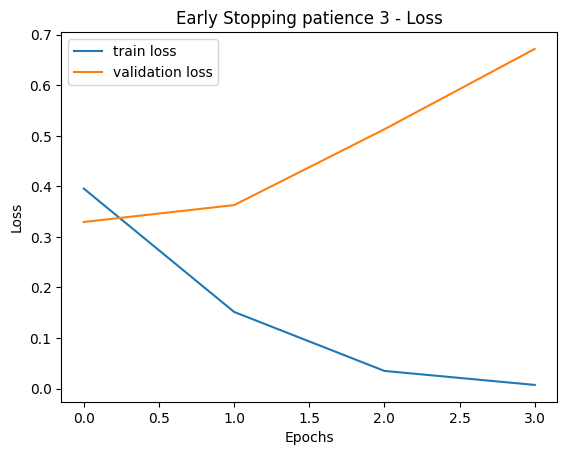

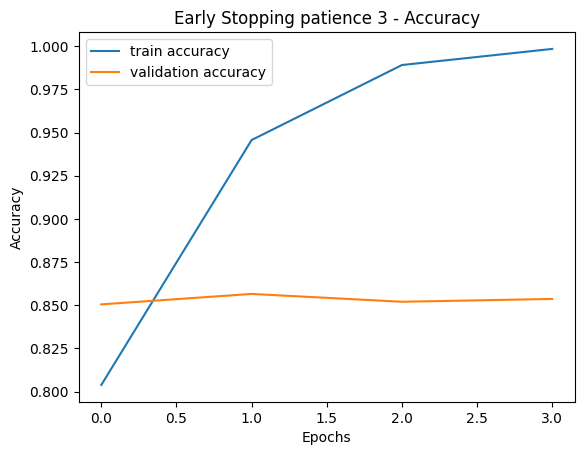

In [16]:
# Early Stopping patience = 1

early_stop_1 = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

# Modelo con Early Stopping patience = 1

model_es_1 = Sequential([

    Input(shape=(200,)),

    Embedding(
        input_dim=10000,
        output_dim=32
    ),

    Flatten(),

    Dense(16, activation='relu'),

    Dense(8, activation='relu'),

    Dense(1, activation='sigmoid')
])

# Compilacion del modelo

model_es_1.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento del modelo

history_es_1 = model_es_1.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_1]
)

# Predicciones del modelo

y_pred_es_1 = model_es_1.predict(X_test)
y_pred_es_1 = (y_pred_es_1 > 0.5).astype(int)

# Calculo de metricas

accuracy_es_1 = accuracy_score(y_test, y_pred_es_1)
precision_es_1 = precision_score(y_test, y_pred_es_1)
recall_es_1 = recall_score(y_test, y_pred_es_1)
f1_es_1 = f1_score(y_test, y_pred_es_1)

# Mostrar metricas

print("Metricas Early Stopping patience = 1")
print("--------------------------------------")
print("Accuracy :", accuracy_es_1)
print("Precision:", precision_es_1)
print("Recall   :", recall_es_1)
print("F1-score :", f1_es_1)

# Mostrar epoca final

print("Entrenamiento detenido en epoch:", len(history_es_1.history['loss']))

# Grafico de loss

plt.plot(history_es_1.history['loss'], label='train loss')
plt.plot(history_es_1.history['val_loss'], label='validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Early Stopping patience 1 - Loss')

plt.legend()
plt.show()

# Grafico de accuracy

plt.plot(history_es_1.history['accuracy'], label='train accuracy')
plt.plot(history_es_1.history['val_accuracy'], label='validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Early Stopping patience 1 - Accuracy')

plt.legend()
plt.show()


# Early Stopping patience = 3

early_stop_3 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Modelo con Early Stopping patience = 3

model_es_3 = Sequential([

    Input(shape=(200,)),

    Embedding(
        input_dim=10000,
        output_dim=32
    ),

    Flatten(),

    Dense(16, activation='relu'),

    Dense(8, activation='relu'),

    Dense(1, activation='sigmoid')
])

# Compilacion del modelo

model_es_3.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento del modelo

history_es_3 = model_es_3.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_3]
)

# Predicciones del modelo

y_pred_es_3 = model_es_3.predict(X_test)
y_pred_es_3 = (y_pred_es_3 > 0.5).astype(int)

# Calculo de metricas

accuracy_es_3 = accuracy_score(y_test, y_pred_es_3)
precision_es_3 = precision_score(y_test, y_pred_es_3)
recall_es_3 = recall_score(y_test, y_pred_es_3)
f1_es_3 = f1_score(y_test, y_pred_es_3)

# Mostrar metricas

print("Metricas Early Stopping patience = 3")
print("--------------------------------------")
print("Accuracy :", accuracy_es_3)
print("Precision:", precision_es_3)
print("Recall   :", recall_es_3)
print("F1-score :", f1_es_3)

# Mostrar epoca final

print("Entrenamiento detenido en epoch:", len(history_es_3.history['loss']))

# Grafico de loss

plt.plot(history_es_3.history['loss'], label='train loss')
plt.plot(history_es_3.history['val_loss'], label='validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Early Stopping patience 3 - Loss')

plt.legend()
plt.show()

# Grafico de accuracy

plt.plot(history_es_3.history['accuracy'], label='train accuracy')
plt.plot(history_es_3.history['val_accuracy'], label='validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Early Stopping patience 3 - Accuracy')

plt.legend()
plt.show()

## Data Augmentation con Ruido Gaussiano

En esta seccion se implementa una tecnica simple de Data Augmentation sobre una nueva copia del modelo baseline. La tecnica consiste en agregar pequeñas perturbaciones aleatorias mediante ruido gaussiano a los datos de entrenamiento.

El objetivo es generar variaciones artificiales de los datos originales para dificultar la memorizacion exacta del conjunto de entrenamiento y mejorar la capacidad de generalizacion del modelo.

Posteriormente, los datos originales y aumentados se combinaran para entrenar nuevamente el modelo y comparar sus metricas y curvas de entrenamiento respecto al baseline.

Epoch 1/5
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.8237 - loss: 0.3745 - val_accuracy: 0.8482 - val_loss: 0.3433
Epoch 2/5
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9581 - loss: 0.1154 - val_accuracy: 0.8918 - val_loss: 0.2838
Epoch 3/5
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9911 - loss: 0.0278 - val_accuracy: 0.8889 - val_loss: 0.3751
Epoch 4/5
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9936 - loss: 0.0182 - val_accuracy: 0.8876 - val_loss: 0.4159
Epoch 5/5
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9933 - loss: 0.0186 - val_accuracy: 0.8883 - val_loss: 0.4406
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Metricas Data Augmentation
----------------------------
Accuracy : 0.8464253302410003
Precision: 0.8347219531098624
Recall   : 0.8654077942948976
F1-score : 0.8497879475293422


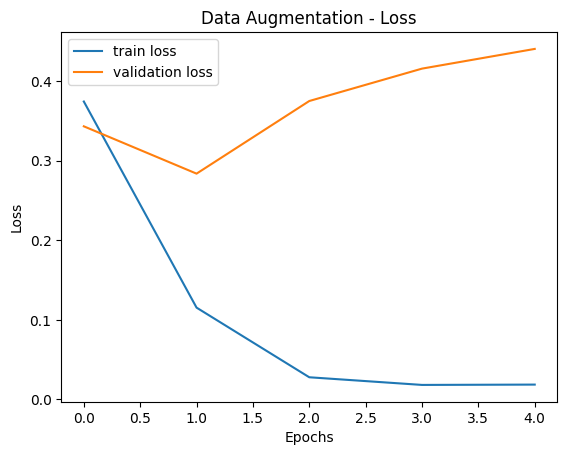

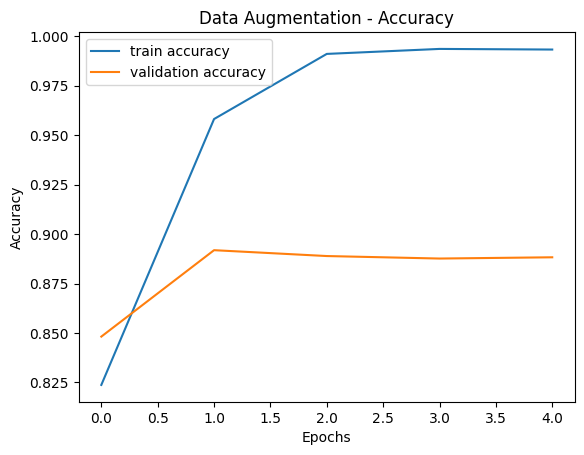

In [17]:
# Generacion de ruido gaussiano

X_aug = X_train + 0.01 * np.random.randn(*X_train.shape)

# Combinacion de datos originales y aumentados

X_combined = np.vstack([X_train, X_aug])
y_combined = np.hstack([y_train, y_train])

# Modelo con Data Augmentation

model_aug = Sequential([

    Input(shape=(200,)),

    Embedding(
        input_dim=10000,
        output_dim=32
    ),

    Flatten(),

    Dense(16, activation='relu'),

    Dense(8, activation='relu'),

    Dense(1, activation='sigmoid')
])

# Compilacion del modelo

model_aug.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento del modelo

history_aug = model_aug.fit(
    X_combined,
    y_combined,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# Predicciones del modelo

y_pred_aug = model_aug.predict(X_test)
y_pred_aug = (y_pred_aug > 0.5).astype(int)

# Calculo de metricas

accuracy_aug = accuracy_score(y_test, y_pred_aug)
precision_aug = precision_score(y_test, y_pred_aug)
recall_aug = recall_score(y_test, y_pred_aug)
f1_aug = f1_score(y_test, y_pred_aug)

# Mostrar metricas

print("Metricas Data Augmentation")
print("----------------------------")
print("Accuracy :", accuracy_aug)
print("Precision:", precision_aug)
print("Recall   :", recall_aug)
print("F1-score :", f1_aug)

# Grafico de loss

plt.plot(history_aug.history['loss'], label='train loss')
plt.plot(history_aug.history['val_loss'], label='validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Data Augmentation - Loss')

plt.legend()
plt.show()

# Grafico de accuracy

plt.plot(history_aug.history['accuracy'], label='train accuracy')
plt.plot(history_aug.history['val_accuracy'], label='validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Data Augmentation - Accuracy')

plt.legend()
plt.show()

## Comparacion General de Resultados

En esta seccion se comparan las curvas de validacion de todos los experimentos realizados sobre el modelo baseline. El objetivo es visualizar de forma directa el impacto de cada tecnica de regularizacion sobre el overfitting y la capacidad de generalizacion del modelo.

Se compararan:
- Validation Loss
- Validation Accuracy

entre:
- Baseline
- L2 Regularization
- Dropout
- Batch Normalization
- Early Stopping
- Data Augmentation

Esto permitira identificar que tecnica redujo mejor el gap entre entrenamiento y validacion, asi como determinar cual obtuvo el comportamiento mas estable durante el entrenamiento.

                Modelo  Accuracy  Precision    Recall  F1-score
0             Baseline  0.861853   0.856945  0.870028  0.863437
1              L2 0.05  0.869719   0.894309  0.839695  0.866142
2          Dropout 0.8  0.858122   0.840679  0.885094  0.862315
3  Batch Normalization  0.849854   0.849249  0.852149  0.850697
4      EarlyStopping 3  0.849450   0.798834  0.935717  0.861874
5    Data Augmentation  0.846425   0.834722  0.865408  0.849788


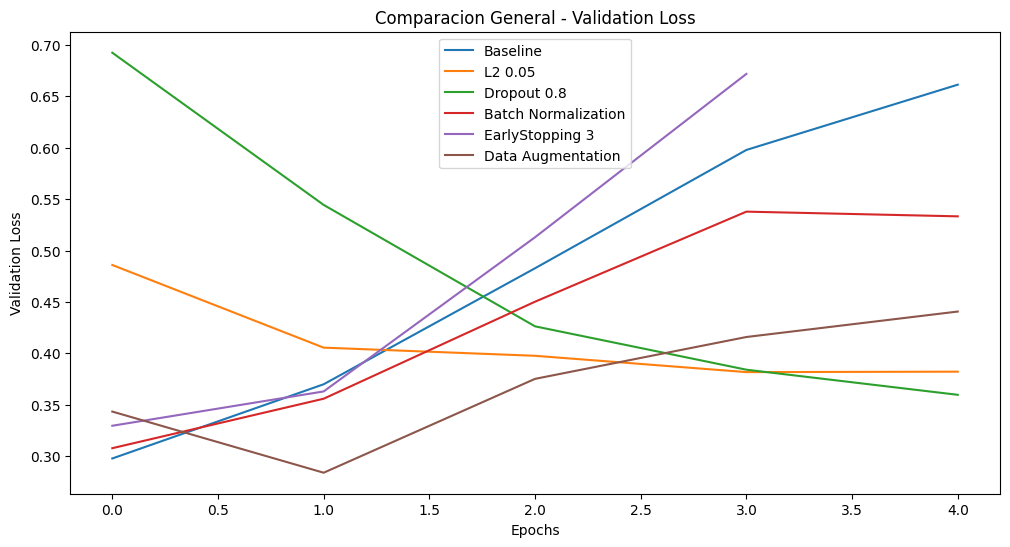

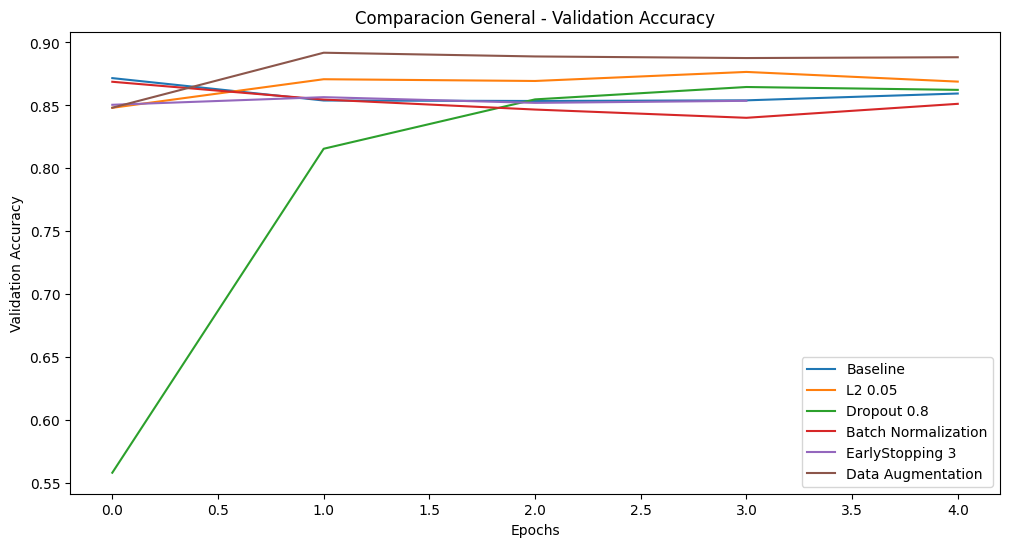

In [21]:
# Tabla comparativa de metricas

results = pd.DataFrame({

    "Modelo": [
        "Baseline",
        "L2 0.05",
        "Dropout 0.8",
        "Batch Normalization",
        "EarlyStopping 3",
        "Data Augmentation"
    ],

    "Accuracy": [
        accuracy,
        accuracy_l2_005,
        accuracy_dropout_08,
        accuracy_bn,
        accuracy_es_3,
        accuracy_aug
    ],

    "Precision": [
        precision,
        precision_l2_005,
        precision_dropout_08,
        precision_bn,
        precision_es_3,
        precision_aug
    ],

    "Recall": [
        recall,
        recall_l2_005,
        recall_dropout_08,
        recall_bn,
        recall_es_3,
        recall_aug
    ],

    "F1-score": [
        f1,
        f1_l2_005,
        f1_dropout_08,
        f1_bn,
        f1_es_3,
        f1_aug
    ]
})

print(results)

# Grafico comparativo de validation loss

plt.figure(figsize=(12,6))

plt.plot(history.history['val_loss'], label='Baseline')

plt.plot(history_l2_005.history['val_loss'], label='L2 0.05')

plt.plot(history_dropout_08.history['val_loss'], label='Dropout 0.8')

plt.plot(history_bn.history['val_loss'], label='Batch Normalization')

plt.plot(history_es_3.history['val_loss'], label='EarlyStopping 3')

plt.plot(history_aug.history['val_loss'], label='Data Augmentation')

plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Comparacion General - Validation Loss')

plt.legend()
plt.show()

# Grafico comparativo de validation accuracy

plt.figure(figsize=(12,6))

plt.plot(history.history['val_accuracy'], label='Baseline')

plt.plot(history_l2_005.history['val_accuracy'], label='L2 0.05')

plt.plot(history_dropout_08.history['val_accuracy'], label='Dropout 0.8')

plt.plot(history_bn.history['val_accuracy'], label='Batch Normalization')

plt.plot(history_es_3.history['val_accuracy'], label='EarlyStopping 3')

plt.plot(history_aug.history['val_accuracy'], label='Data Augmentation')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Comparacion General - Validation Accuracy')

plt.legend()
plt.show()

## Conclusion General

Los experimentos realizados permitieron comprobar que las tecnicas de regularizacion reducen el overfitting y modifican el comportamiento de generalizacion del modelo MLP. El modelo baseline presentaba un sobreajuste evidente, ya que el train loss disminuia rapidamente mientras el validation loss aumentaba progresivamente.

Entre las tecnicas evaluadas, L2 Regularization con lambda = 0.05 obtuvo el mejor accuracy general (86.97%) y el mejor precision score (89.43%), demostrando una buena capacidad para reducir falsos positivos y limitar pesos excesivamente grandes dentro de la red neuronal.

Dropout con tasa 0.8 obtuvo el recall mas equilibrado junto con un F1-score competitivo, mostrando una buena capacidad de generalizacion y una reduccion visible del overfitting en las curvas de validacion.

Early Stopping con patience = 3 alcanzo el recall mas alto (93.57%), aunque con una disminucion importante en precision, indicando que el modelo tendia a clasificar una mayor cantidad de ejemplos como positivos para evitar falsos negativos.

Batch Normalization y Data Augmentation mostraron impactos mas moderados respecto al baseline, estabilizando parcialmente el entrenamiento pero sin superar los mejores resultados obtenidos por L2 y Dropout.

En conclusion, las tecnicas que mostraron el mejor equilibrio general fueron L2 Regularization y Dropout, ya que lograron reducir el overfitting manteniendo metricas competitivas y curvas de validacion mas estables. Tambien se concluye que una regularizacion excesiva puede deteriorar el desempeño del modelo y provocar underfitting, por lo que la configuracion de estas tecnicas debe ajustarse cuidadosamente segun el comportamiento observado durante el entrenamiento.